# EDA de validación del corpus SEXTANTE

Objetivo: verificar que `data/raw/vacantes.csv` cumple el esquema canónico de
17 columnas descrito en la documentación, y describir cobertura y calidad de los
campos. Es el insumo de partida para el siguiente entregable (EDA profundo,
extracción de habilidades y NLP).

Fuentes actuales: **El Empleo** (HTML + JSON-LD) y **LinkedIn** (vía JobSpy).
Ver `docs/viabilidad_fuentes.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # raíz del proyecto (accede a src/)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

RUTA = "../data/raw/vacantes.csv"
df = pd.read_csv(RUTA)
df.shape

(218, 17)

## 1. Cumplimiento del esquema canónico

In [2]:
from src.extraccion.esquema import COLUMNAS_ESQUEMA, validar
faltantes = validar(df)
print("columnas canónicas:", len(COLUMNAS_ESQUEMA))
print("columnas en el dataset:", list(df.columns))
print("faltantes:", faltantes if faltantes else "ninguna ✔")

columnas canónicas: 17
columnas en el dataset: ['id_vacante', 'portal', 'url', 'titulo', 'empresa', 'ciudad', 'departamento', 'fecha_publicacion', 'descripcion', 'salario_texto', 'salario_min', 'salario_max', 'tipo_contrato', 'modalidad', 'nivel_educativo', 'experiencia_texto', 'fecha_captura']
faltantes: ninguna ✔


## 2. Cobertura por portal y no nulos

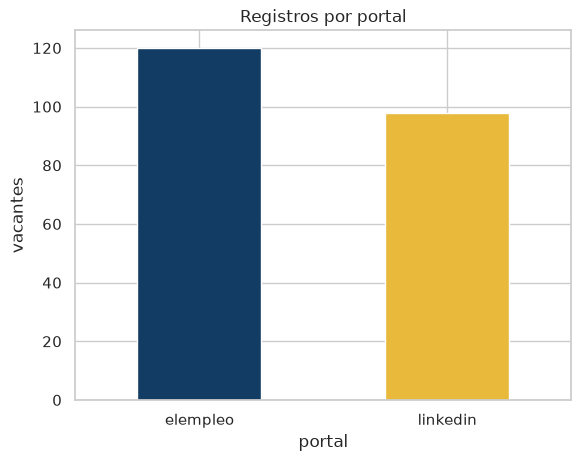

In [3]:
df["portal"].value_counts().plot(kind="bar", color=["#123c63", "#e8b93a"])
plt.title("Registros por portal")
plt.ylabel("vacantes")
plt.xticks(rotation=0)
plt.show()

In [4]:
cobertura = pd.DataFrame({
    "no_nulos": df.notna().sum(),
    "cobertura_%": (df.notna().sum() / len(df) * 100).round(1),
}).sort_values("no_nulos", ascending=False)
cobertura

,no_nulos,cobertura_%
id_vacante,218,100.0
portal,218,100.0
url,218,100.0
titulo,218,100.0
empresa,218,100.0
fecha_captura,218,100.0
fecha_publicacion,216,99.1
tipo_contrato,206,94.5
descripcion,206,94.5
ciudad,122,56.0


In [5]:
print("duplicados por url:", int(df.duplicated("url").sum()))
print("ids únicos:", df["id_vacante"].nunique())

duplicados por url: 0
ids únicos: 218


## 3. Campos estructurados clave

In [6]:
df["tipo_contrato"].value_counts(dropna=False).head(12)

tipo_contrato
Tiempo completo    128
Por día             50
Temporal            22
NaN                 12
Contrato             3
Prácticas            2
Otro                 1
Name: count, dtype: int64

In [7]:
df["modalidad"].value_counts(dropna=False)

modalidad
NaN       202
Remoto     16
Name: count, dtype: int64

In [8]:
sal = df[["salario_min", "salario_max"]].apply(pd.to_numeric, errors="coerce")
print(f"salario_min no nulos: {sal['salario_min'].notna().sum()}")
if sal["salario_min"].notna().any():
    print("rango salario_min:", sal["salario_min"].min(), "→", sal["salario_min"].max())
    print("ejemplos salario_texto:")
    print(df["salario_texto"].dropna().head(5).to_string(index=False))

salario_min no nulos: 94
rango salario_min: 0.0 → 6000001.0
ejemplos salario_texto:
  $1,5 a $2 millones
  $4 a $4,5 millones
$4,5 a $5,5 millones
  $1,5 a $2 millones
$4,5 a $5,5 millones


In [9]:
df["fecha_publicacion"] = pd.to_datetime(df["fecha_publicacion"], errors="coerce")
df["fecha_captura"] = pd.to_datetime(df["fecha_captura"], errors="coerce")
print("periodo publicado:", df["fecha_publicacion"].min(), "→", df["fecha_publicacion"].max())
print("captura:", df["fecha_captura"].dropna().min(), "→", df["fecha_captura"].dropna().max())
print("días publicación→captura (mediana):",
      (df["fecha_captura"] - df["fecha_publicacion"]).dt.days.median())

periodo publicado: 2025-01-31 00:00:00 → 2026-09-20 00:00:00
captura: 2026-09-20 00:00:00 → 2026-09-20 00:00:00
días publicación→captura (mediana): 18.0


## 4. Descripciones y ubicación

In [10]:
print("descripciones no vacías:", df["descripcion"].notna().sum())
long = df["descripcion"].dropna().astype(str).str.len()
print("largo de descripción: mediana", long.median().round(0), "| máx", long.max())
print("ciudades no nulas:", df["ciudad"].notna().sum())
df["ciudad"].value_counts().head(8)

descripciones no vacías: 206
largo de descripción: mediana 1370.0 | máx 20517
ciudades no nulas: 122


ciudad
Medellín        20
Barranquilla    20
Cali            20
Cartagena       20
Bogotá          19
Bucaramanga     17
Antioquia        2
Cajicá           1
Name: count, dtype: int64

In [11]:
from collections import Counter
import re
palabras = Counter()
for d in df["descripcion"].dropna().astype(str):
    palabras.update(re.findall(r"[a-záéíóúñü]{4,}", d.lower()))
palabras.most_common(12)

[('para', 621),
 ('experiencia', 435),
 ('gestión', 168),
 ('profesional', 167),
 ('equipo', 153),
 ('trabajo', 149),
 ('como', 147),
 ('clientes', 135),
 ('manejo', 132),
 ('cumplimiento', 127),
 ('procesos', 126),
 ('comercial', 126)]

## 5. Resumen de estado

In [12]:
con_desc = df["descripcion"].notna().mean()
con_sal = (df["salario_texto"].notna() | df["salario_min"].notna()).mean()
print(f"{len(df)} vacantes · {df['portal'].nunique()} portales · "
      f"descripción completa en {con_desc:.0%} · salario en {con_sal:.0%}")
print()
print("PENDIENTE de extracción (siguiente etapa de NLP):")
print(" - departamento, nivel_educativo, experiencia_texto (0% de cobertura)")
print(" - salario numérico en LinkedIn")
print(" - normalización de moneda y escala del salario_texto")

218 vacantes · 2 portales · descripción completa en 94% · salario en 55%

PENDIENTE de extracción (siguiente etapa de NLP):
 - departamento, nivel_educativo, experiencia_texto (0% de cobertura)
 - salario numérico en LinkedIn
 - normalización de moneda y escala del salario_texto
